# IAT 461 / 882 — Assignment 2: Modeling Phigma User Behavior

**Name:** `[Tawshif Al Mehrab]`  
**SFU ID:** `[301540260]`  
**Date:** `[July 1st 2026]`

---

> Before you start: read the full assignment README on Canvas.  
> Run cells top-to-bottom. Do **not** skip cells — later cells depend on earlier ones.  
> Every cell marked `# YOUR CODE HERE` must be completed.  
> Every cell marked `**✏️ Your interpretation:**` must be filled in with your own words.


## Setup

Run this cell first. It imports all libraries used throughout the notebook.

In [108]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, classification_report,roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
# Plot style
plt.rcParams.update({'figure.dpi': 120,'axes.spines.top': False,'axes.spines.right': False,'axes.titlesize': 13,'axes.labelsize': 11,})
ACCENT = '#e8925a'   # course accent colour
print("library loaded")

library loaded


---

## Part A — Linear Regression: Did the AI Assistant Change User Behavior?

**Dataset:** `phigma_ab_study.csv`  
**Research question:** Does access to Phigma's AI design assistant increase whiteboard session duration among free-tier users?

This is a **between-subjects experiment**. Users were randomly assigned to treatment (AI access) or control (no AI). We use OLS regression to estimate the effect of the treatment while controlling for other variables.

> **No train/test split in this part.** We are doing statistical inference — explaining the outcome — not predicting future users.


### Load the data

In [39]:
df_ab = pd.read_csv("phigma_ab_study.csv", keep_default_na=False)
print(f"Shape: {df_ab.shape}")
print(f"\nColumn types:\n{df_ab.dtypes}")
print(f"\nFirst 3 rows:")
df_ab.head(3)

Shape: (2000, 12)

Column types:
user_id                                    str
ab_group                                   str
device_type                                str
account_age_days                         int64
prior_whiteboard_sessions                int64
plan_region                                str
num_collaborators                        int64
feature_tour_completed                   int64
templates_used                           int64
ai_suggestions_used                      int64
whiteboard_actions_per_session           int64
avg_whiteboard_session_duration_min    float64
dtype: object

First 3 rows:


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
0,U76582,control,tablet,478,4,EU,3,1,0,0,67,29.70
1,U49158,control,desktop,633,9,APAC,1,0,1,0,72,32.32
2,U82668,control,desktop,159,10,NA,5,1,1,0,38,17.91


In [40]:
# Summary statistics
df_ab.describe(include='all').round(2)


,user_id,ab_group,device_type,account_age_days,prior_whiteboard_sessions,plan_region,num_collaborators,feature_tour_completed,templates_used,ai_suggestions_used,whiteboard_actions_per_session,avg_whiteboard_session_duration_min
count,2000,2000,2000,2000.00,2000.00,2000,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
unique,1978,2,3,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN
top,U21640,control,desktop,NaN,NaN,NA,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,1011,1211,NaN,NaN,677,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,356.43,4.51,NaN,2.16,0.58,2.79,3.63,84.55,39.53
std,NaN,NaN,NaN,207.82,3.33,NaN,2.37,0.49,2.33,4.87,44.35,20.18
min,NaN,NaN,NaN,7.00,0.00,NaN,0.00,0.00,0.00,0.00,8.00,6.27
25%,NaN,NaN,NaN,178.00,2.00,NaN,0.00,0.00,1.00,0.00,54.00,25.51
50%,NaN,NaN,NaN,352.50,4.00,NaN,1.00,1.00,2.00,0.00,76.00,35.40
75%,NaN,NaN,NaN,533.25,6.00,NaN,3.00,1.00,4.00,7.00,106.00,48.93


In [41]:
# Missing values
df_ab.isnull().sum()

user_id                                0
ab_group                               0
device_type                            0
account_age_days                       0
prior_whiteboard_sessions              0
plan_region                            0
num_collaborators                      0
feature_tour_completed                 0
templates_used                         0
ai_suggestions_used                    0
whiteboard_actions_per_session         0
avg_whiteboard_session_duration_min    0
dtype: int64

### Initial Data Inspection

firstl loaded the A/B experiment dataset and inspected its shape, column names, data types, missing values, and summary statistics, `keep_default_na=False` because the dataset contains `"NA"` as a valid region label, not as a missing value. This prevents North America from being incorrectly treated as null data

### A1 — Exploratory Data Analysis

#### A1.1 — Outcome distribution


BEGIN
    Load target outcome variable

    // 1. Normality & Transformation Visualizations
    Initialize three-panel visual layout
    
    Draw histogram of raw outcome distribution
    Transform outcome variable using natural logarithm
    Draw histogram of log-transformed outcome distribution
    Draw Q-Q plot comparing log-transformed distribution to a normal distribution
    
    Render visualizations

    // 2. Statistical Diagnostics
    Compute and output skewness for both raw and log-transformed distributions
END

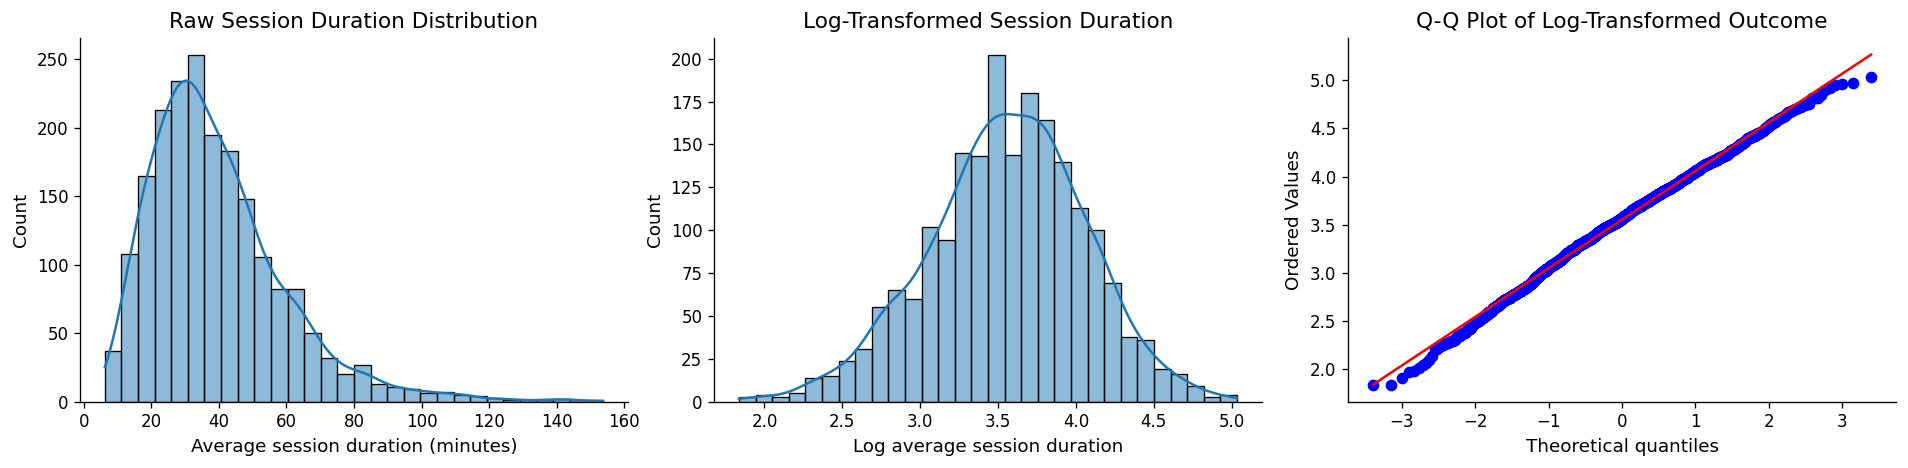

Raw outcome skewness: 1.3767967385922617
Log-transformed outcome skewness: -0.21346835587826904


In [42]:
# Load dataset
ab = pd.read_csv("phigma_ab_study.csv", keep_default_na=False)
# Target outcome
outcome = ab["avg_whiteboard_session_duration_min"]
# Log-transform outcome
ab["log_avg_whiteboard_session_duration_min"] = np.log(outcome)
#  plots
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
sns.histplot(outcome, bins=30, kde=True)
plt.title("Raw Session Duration Distribution")
plt.xlabel("Average session duration (minutes)")
plt.ylabel("Count")
plt.subplot(1, 3, 2)
sns.histplot(ab["log_avg_whiteboard_session_duration_min"], bins=30, kde=True)
plt.title("Log-Transformed Session Duration")
plt.xlabel("Log average session duration")
plt.ylabel("Count")
plt.subplot(1, 3, 3)
stats.probplot(ab["log_avg_whiteboard_session_duration_min"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Transformed Outcome")
plt.tight_layout()
plt.show()
# skewnescomparison
raw_skew = outcome.skew()
log_skew = ab["log_avg_whiteboard_session_duration_min"].skew()

print("Raw outcome skewness:", raw_skew)
print("Log-transformed outcome skewness:", log_skew)

**✏️ Your interpretation (A1.1):**


The raw average whiteboard session duration is positively skewed, meaning most users have shorter sessions while a smaller number of users have much longer sessions, which is is shown by the long right tail in the raw histogram and the raw skewness value of about 1.38, after applying a natural log transformation, the distribution becomes much more symmetric, with skewness decreasing to about -0.21. The Q -Q plot of the log transformed outcome also follows the reference line fairly closely, especially through the middle of the distribution, which suggests the transformed outcome is closer to normal.

just because the log transformed outcome better satisfies the normality expectations for OLS regression, I will use `log_avg_whiteboard_session_duration_min` as the response variable in the regression models.

#### A1.2 — Examine the confounders

// Define the analytical pipeline
BEGIN
    Load AB testing dataset

    // 1. Visual Exploratory Data Analysis
    Initialize side-by-side visualization layouts
    
    Draw boxplot comparison of AI suggestion usage across experimental groups
    Draw scatter plot comparing whiteboard activity density against session durations
    
    Optimize layout and display visualizations

    // 2. Statistical Analysis
    Calculate and print the correlation between whiteboard activity and session duration
    Calculate and print descriptive statistics for AI suggestion usage grouped by treatment group
END

**✏️ Your interpretation (A1.2):**
Why should neither be included in your model?*
confounder check shows that `ai_suggestions_used` should not be included in the main OLS model. In the control group, users have zero AI suggestions used, while treatment users use an average of about 7.33 suggestions. This means the variable is not a clean pre-treatment predictons, it exists because some users received access to the AI assistant.

`whiteboard_actions_per_session` is also problematic because it is extremely correlated with log session duration, with a correlation of about 0.91. This suggests it is almost acting like a proxy for the outcome itself. Longer sessions naturally give users more time to perform whiteboard actions, so including this variable could make the model explain session duration using something that is partly produced by session duration.

Because of this, I exclude both variables from the main model. This keeps the regression focused on treatment assignment and user characteristics that are not direct consequences of the session outcome.

#### A1.3 — Predictor distributions and relationships with outcome

BEGIN
    Define list of numerical predictor variables
    Compute log-transformed outcome variable

    Initialize visual grid layout (2 rows by N columns, where N is the number of predictors)

    FOR each predictor variable:
        // Top row: Univariate Analysis
        Draw histogram to show distribution of the predictor
        
        // Bottom row: Bivariate Analysis
        Draw scatter plot comparing predictor against log-transformed outcome
        Calculate correlation coefficient between predictor and log-transformed outcome
        Annotate plot with correlation coefficient
    END FOR

    Add global title and render layout
END

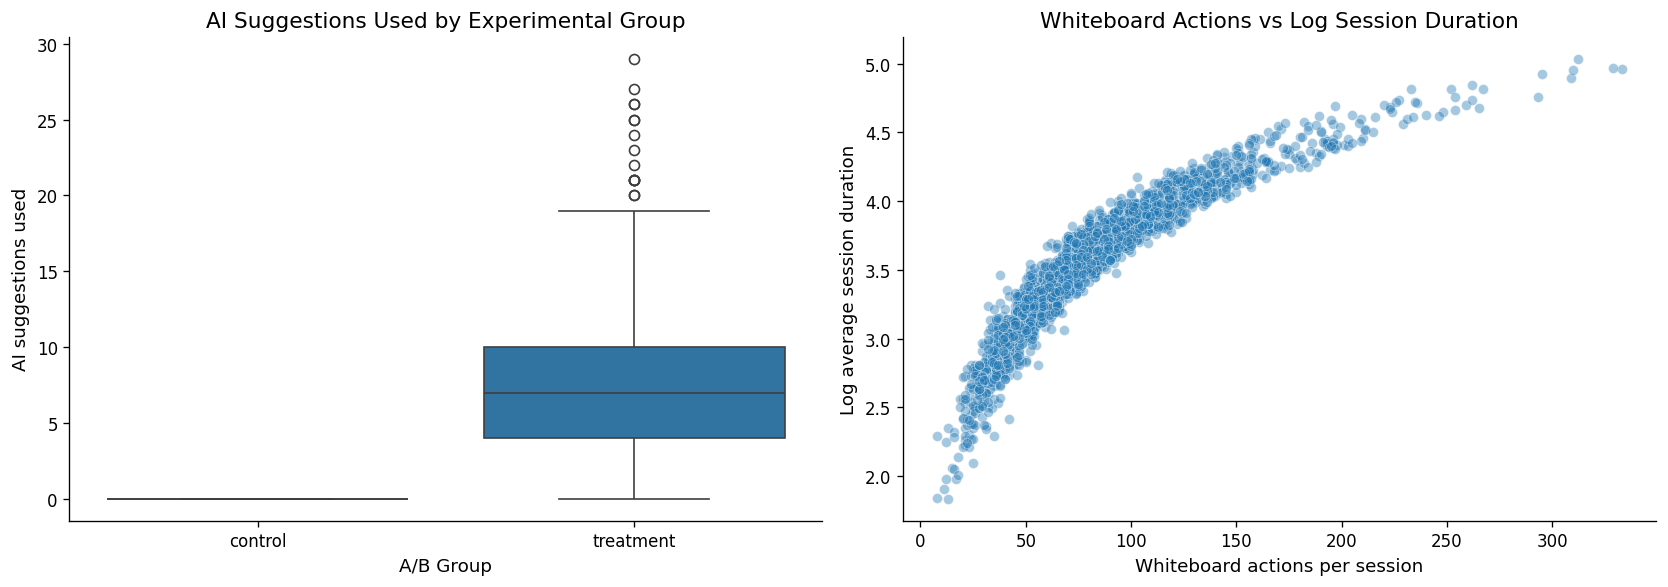

Correlation between whiteboard actions per session and log session duration:
0.913561463800568

AI suggestions used by experimental group:
            count      mean       std  min  25%  50%   75%   max
ab_group                                                        
control    1011.0  0.000000  0.000000  0.0  0.0  0.0   0.0   0.0
treatment   989.0  7.334681  4.550684  0.0  4.0  7.0  10.0  29.0


In [74]:
ab = pd.read_csv("phigma_ab_study.csv", keep_default_na=False)
ab["log_avg_whiteboard_session_duration_min"] = np.log(ab["avg_whiteboard_session_duration_min"])
plt.figure(figsize=(14, 5))
# 1. AI suggestions by experimental group
plt.subplot(1, 2, 1)
sns.boxplot(data=ab,x="ab_group",y="ai_suggestions_used")
plt.title("AI Suggestions Used by Experimental Group")
plt.xlabel("A/B Group")
plt.ylabel("AI suggestions used")
# actions per session vs log session duration
plt.subplot(1, 2, 2)
sns.scatterplot(data=ab,x="whiteboard_actions_per_session",y="log_avg_whiteboard_session_duration_min",alpha=0.4)
plt.title("Whiteboard Actions vs Log Session Duration")
plt.xlabel("Whiteboard actions per session")
plt.ylabel("Log average session duration")
plt.tight_layout()
plt.show()
# statistical summaries
activity_corr = ab["whiteboard_actions_per_session"].corr(ab["log_avg_whiteboard_session_duration_min"])
print("Correlation between whiteboard actions per session and log session duration:")
print(activity_corr)

print("\nAI suggestions used by experimental group:")
print(ab.groupby("ab_group")["ai_suggestions_used"].describe())

BEGIN
    Define list of categorical predictor variables
    Initialize visual grid layout (1 row by N columns, where N is the number of categories)

    FOR each categorical variable:
        Retrieve unique category levels
        
        Group log-transformed outcome values by category levels
        
        Draw boxplots of log-transformed outcome grouped by category level
        Rotate category axis labels for readability
        
        Label axis and set titles
    END FOR

    Render layout
END

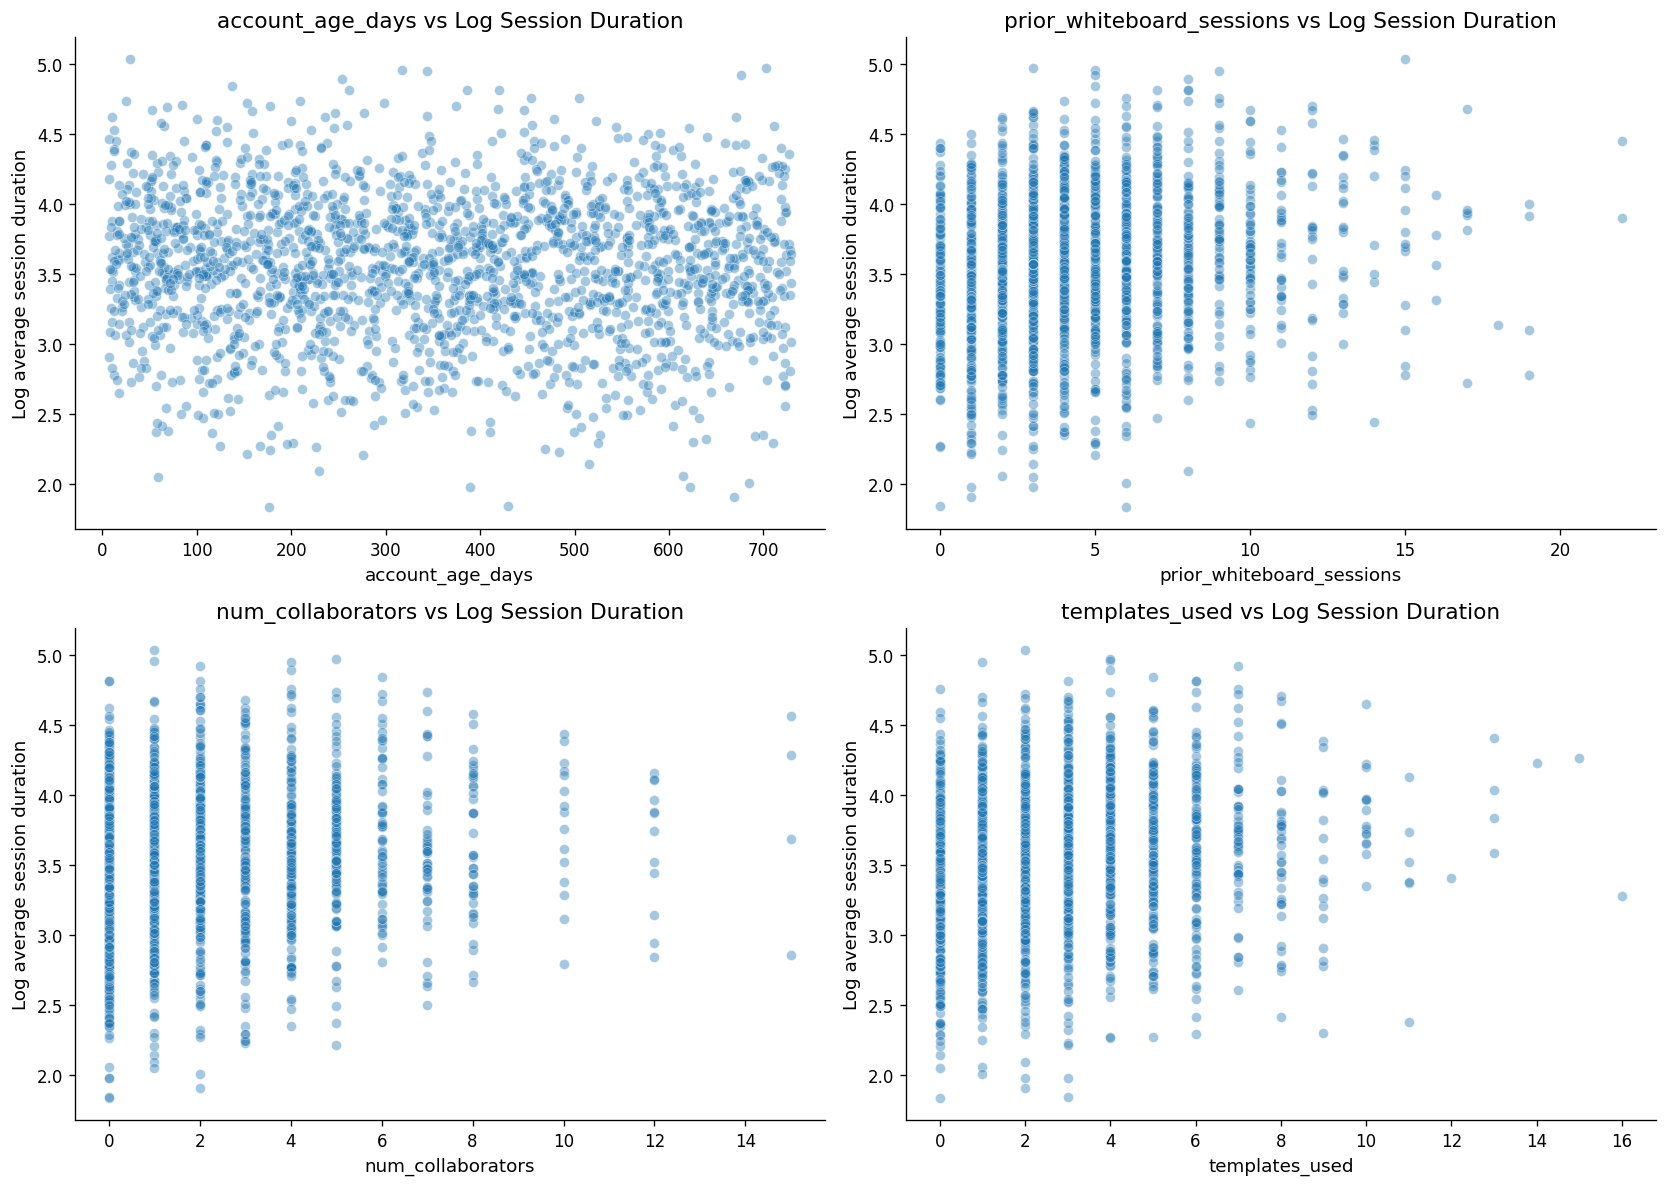

Correlations with log session duration:
log_avg_whiteboard_session_duration_min    1.000000
prior_whiteboard_sessions                  0.181838
templates_used                             0.160232
num_collaborators                          0.107030
account_age_days                          -0.034814
Name: log_avg_whiteboard_session_duration_min, dtype: float64


In [77]:
numeric_predictors = ["account_age_days","prior_whiteboard_sessions","num_collaborators","templates_used"]
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_predictors, 1):
    plt.subplot(2, 2, i)
    sns.scatterplot(data=ab,x=col,y="log_avg_whiteboard_session_duration_min",alpha=0.4)
    plt.title(f"{col} vs Log Session Duration")
    plt.xlabel(col)
    plt.ylabel("Log average session duration")
plt.tight_layout()
plt.show()
# Correlations with log outcome
correlations = ab[numeric_predictors + ["log_avg_whiteboard_session_duration_min"]].corr()
print("Correlations with log session duration:")
print(correlations["log_avg_whiteboard_session_duration_min"].sort_values(ascending=False))

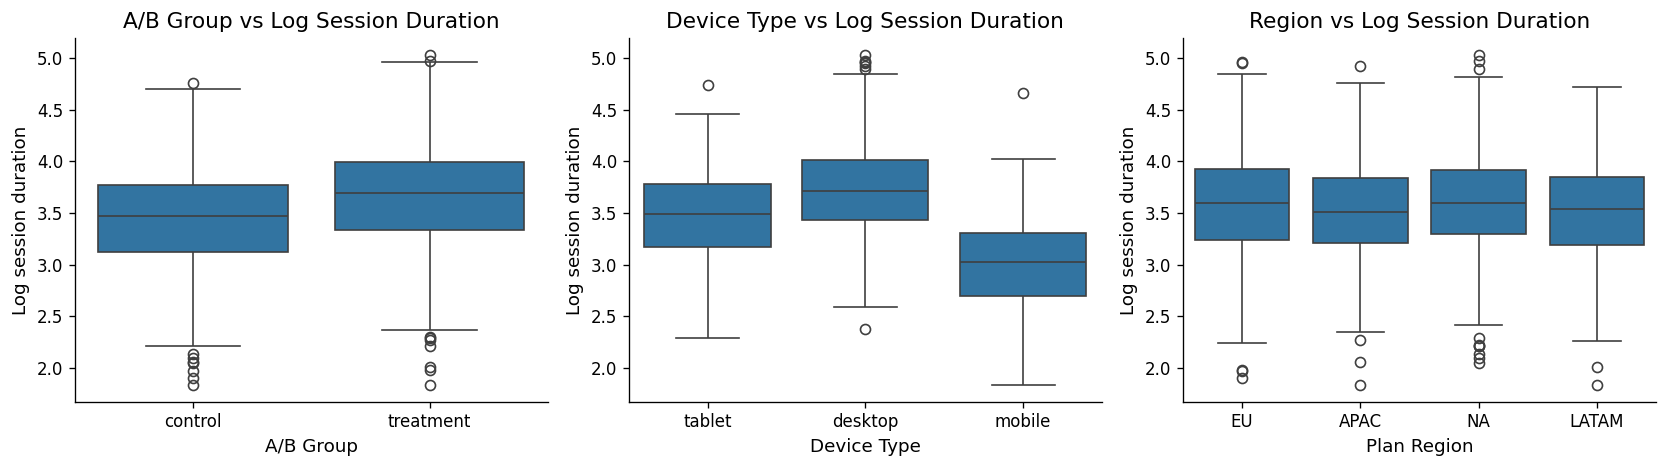

mean log session duration by A/B group-
ab_group
control      3.442871
treatment    3.667399
Name: log_avg_whiteboard_session_duration_min, dtype: float64

Mean log session duration by device type:
device_type
desktop    3.723352
mobile     2.995677
tablet     3.467085
Name: log_avg_whiteboard_session_duration_min, dtype: float64

Mean log session duration by plan region:
plan_region
APAC     3.505416
EU       3.567868
LATAM    3.508301
NA       3.593004
Name: log_avg_whiteboard_session_duration_min, dtype: float64


In [78]:
plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
sns.boxplot(data=ab, x="ab_group", y="log_avg_whiteboard_session_duration_min")
plt.title("A/B Group vs Log Session Duration")
plt.xlabel("A/B Group")
plt.ylabel("Log session duration")
plt.subplot(1, 3, 2)
sns.boxplot(data=ab, x="device_type", y="log_avg_whiteboard_session_duration_min")
plt.title("Device Type vs Log Session Duration")
plt.xlabel("Device Type")
plt.ylabel("Log session duration")
plt.subplot(1, 3, 3)
sns.boxplot(data=ab, x="plan_region", y="log_avg_whiteboard_session_duration_min")
plt.title("Region vs Log Session Duration")
plt.xlabel("Plan Region")
plt.ylabel("Log session duration")
plt.tight_layout()
plt.show()
print("mean log session duration by A/B group-")
print(ab.groupby("ab_group")["log_avg_whiteboard_session_duration_min"].mean())
print("\nMean log session duration by device type:")
print(ab.groupby("device_type")["log_avg_whiteboard_session_duration_min"].mean())

print("\nMean log session duration by plan region:")
print(ab.groupby("plan_region")["log_avg_whiteboard_session_duration_min"].mean())

**✏️ Your interpretation (A1.3):**

*3–5 sentences summarizing your EDA. Which predictors look most promising? Are any right-skewed and worth log-transforming before use as predictors? Which two features are you excluding and why?*
 
EDA suggests that treatment group, device type, prior whiteboard sessions, & templates used are the most promising predictors of session duration. Treatment users generally show higher log session duration than control users, while desktop users tend to have longer sessions than mobile users. Among the numeric predictors, `prior_whiteboard_sessions` and `templates_used` show the clearest positive relationships with the outcome, while `account_age_days` appears weak.

Some count variables, especially `prior_whiteboard_sessions`, `num_collaborators`, and `templates_used`, are right-skewed and are worth log-transforming using `log1p()` before modeling. I exclude `ai_suggestions_used` because it is only meaningful for the treatment group and happens after treatment assignment, also excluded `whiteboard_actions_per_session` because it is extremely correlated with session duration and may act as a proxy for the outcome rather than an independent predictor.

### A1 Summary

the raw session duration outcome was right skewed- but the log transformation made the distribution much closer to normal, so I will use the logtransformed outcome for OLS regression. Treatment users appear to have longer sessions than control users, and desktop users tend to have longer sessions than mobile users. Among numeric predictors, prior whiteboard sessions and templates used show the clearest positive relationships with session duration, while account age has little relationship.

I will not include `ai_suggestions_used` in the main model because it is only available for treatment users and happens after treatment assignment, also exclude `whiteboard_actions_per_session` because it is extremely correlated with session duration and may act as a near proxy for the outcome rather than a clean explanatory predictor

### A2 — Feature Engineering

Prepare your feature matrix for OLS. Exclude the two problematic variables identified in A1.


BEGIN
    Load baseline dataset

    // 1. Encode Categorical Variables
    Convert experimental group ('ab_group') into a binary integer indicator
    Generate dummy indicators (one-hot encoding) for device types, omitting the first category
    Generate dummy indicators (one-hot encoding) for regions, omitting the first category

    // 2. Perform Optional Transformations
    Log-transform right-skewed numerical predictors using log(x + 1) to avoid zero values

    // 3. Assemble Modeling Dataset
    Merge numerical characteristics, binary groups, and dummy indicators into matrix X
    Set target vector y as the log-transformed outcome variable

    // 4. Quality Control
    Verify that there are no missing (null) values in feature matrix X
    Inspect matrix dimensions and print a preview of the processed data
END

In [79]:
#Reload baseline dataset
ab = pd.read_csv("phigma_ab_study.csv", keep_default_na=False)
ab["log_avg_whiteboard_session_duration_min"] = np.log(
    ab["avg_whiteboard_session_duration_min"]
)
ab["treatment"] = (ab["ab_group"] == "treatment").astype(int)
# Log-transform right-skewed numeric predictors using log1p to handle zeros
ab["log_prior_whiteboard_sessions"] = np.log1p(ab["prior_whiteboard_sessions"])
ab["log_num_collaborators"] = np.log1p(ab["num_collaborators"])
ab["log_templates_used"] = np.log1p(ab["templates_used"])
device_dummies = pd.get_dummies(ab["device_type"],prefix="device",drop_first=True,dtype=int)
region_dummies = pd.get_dummies(ab["plan_region"],prefix="region",drop_first=True,dtype=int)
#  final feature matrix
X = pd.concat(
    [ ab[["treatment","account_age_days","log_prior_whiteboard_sessions","log_num_collaborators","feature_tour_completed","log_templates_used"]],device_dummies,region_dummies],axis=1)
# Outcome variable
y = ab["log_avg_whiteboard_session_duration_min"]
print("Feature matrix shape:", X.shape)
print("Outcome shape:", y.shape)
print("\nMissing values in X:")
print(X.isnull().sum())
print("\nPreview of final feature matrix:")
display(X.head())

print("\nFinal feature columns:")
print(X.columns.tolist())

Feature matrix shape: (2000, 11)
Outcome shape: (2000,)

Missing values in X:
treatment                        0
account_age_days                 0
log_prior_whiteboard_sessions    0
log_num_collaborators            0
feature_tour_completed           0
log_templates_used               0
device_mobile                    0
device_tablet                    0
region_EU                        0
region_LATAM                     0
region_NA                        0
dtype: int64

Preview of final feature matrix:


,treatment,account_age_days,log_prior_whiteboard_sessions,log_num_collaborators,feature_tour_completed,log_templates_used,device_mobile,device_tablet,region_EU,region_LATAM,region_NA
0,0,478,1.609438,1.386294,1,0.000000,0,1,1,0,0
1,0,633,2.302585,0.693147,0,0.693147,0,0,0,0,0
2,0,159,2.397895,1.791759,1,0.693147,0,0,0,0,1
3,0,7,1.791759,0.693147,0,1.098612,0,0,0,0,1
4,0,44,1.386294,0.000000,1,1.791759,1,0,0,0,1



Final feature columns:
['treatment', 'account_age_days', 'log_prior_whiteboard_sessions', 'log_num_collaborators', 'feature_tour_completed', 'log_templates_used', 'device_mobile', 'device_tablet', 'region_EU', 'region_LATAM', 'region_NA']


**✏️ Your interpretation (A2):**


 final feature matrix includes the treatment indicator, user history variables, collaboration variables, onboarding completion, template usage, device type, and region- encoded `ab_group` as a binary treatment variable so the OLS coefficient can directly estimate the difference between AI access and control

Used `log1p()` transformations for prior whiteboard sessions, number of collaborators, and templates used because these count variables are right skewed and include zero values. Device type and region were one hot encoded with one category dropped to avoid perfect multicollinearity.

I excluded `ai_suggestions_used` and `whiteboard_actions_per_session` because they were identified in A1 as problematic post treatment. the final feature matrix contains no missing values, so it is ready for OLS regression.

### A3 — OLS Regression


In [80]:
# Add intercept term for statsmodels
X_ols = sm.add_constant(X)
# Fit OLS model using log-transformed outcome
ols_model = sm.OLS(y, X_ols).fit()
# Print full regression summary
print(ols_model.summary())

                                       OLS Regression Results                                      
Dep. Variable:     log_avg_whiteboard_session_duration_min   R-squared:                       0.369
Model:                                                 OLS   Adj. R-squared:                  0.365
Method:                                      Least Squares   F-statistic:                     105.7
Date:                                     Thu, 02 Jul 2026   Prob (F-statistic):          1.19e-189
Time:                                             02:26:26   Log-Likelihood:                -1011.0
No. Observations:                                     2000   AIC:                             2046.
Df Residuals:                                         1988   BIC:                             2113.
Df Model:                                               11                                         
Covariance Type:                                 nonrobust                                         


In [81]:
# back transform treatment effect from log scale
treatment_coef = ols_model.params["treatment"]
treatment_pct_effect = (np.exp(treatment_coef) - 1) * 100
baseline_duration = ab.loc[ab["ab_group"] == "control", "avg_whiteboard_session_duration_min"].mean()
estimated_minute_change = baseline_duration * (np.exp(treatment_coef) - 1)
print("Treatment coefficient on log scale:", treatment_coef)
print("Approximate percent effect:", treatment_pct_effect)
print("Control group mean session duration:", baseline_duration)
print("Approximate treatment effect in minutes:", estimated_minute_change)

Treatment coefficient on log scale: 0.17478146834139047
Approximate percent effect: 19.098592004338588
Control group mean session duration: 35.16092977250247
Approximate treatment effect in minutes: 6.715242522182263


### Interpretation (A3)

Based on R2 value of 0.369, the OLS model accounts for approximately 36.9% of the variation in log average session duration. This implies that the explanatory power of the model is moderate. After back-transforming, the treatment coefficient, which is 0.1748 on the log scale and statistically significant with p < 0.001, indicates that access to AI assistants is linked to roughly 19.1% longer sessions, or roughly 6.7 extra minutes, when compared to the control-group mean. This implies that the AI assistant affects session duration in a way that is both practically and statistically significant.
Longer sessions are positively correlated with a number of other statistically significant predictors, including previous whiteboard sessions, the number of collaborators, feature tour completion, and the use of templates. Compared to the baseline desktop group, mobile and tablet users have shorter sessions. which suggests device context matters for whiteboard engagement.

The diagnostic plots look acceptable overall. The residuals are centered around zero without a strong curved pattern, and the Q-Q plot follows the reference line closely through most of the distribution. There are some deviations in the tails, but the log transformation appears to make the OLS assumptions reasonably defensible.

#### A3.1 — Interpret the model

BEGIN
    Input trained OLS regression model
    Input experimental dataframe

    // 1. Evaluate Model Fit
    Display model's R-squared value to assess variance explained

    // 2. Analyze Treatment Effect
    Extract coefficient and significance (p-value) for the A/B testing variable
    Convert the log-space treatment coefficient back to its scale in physical time (minutes) 
    Display treatment effect size and statistical significance

    // 3. Extract Significant Predictors
    Filter all model coefficients where p-value < 0.05
    FOR each significant variable:
        Display variable name, its directional coefficient, and its p-value
    END FOR
END

In [83]:
print("R-squared:", ols_model.rsquared)
print("Adjusted R-squared:", ols_model.rsquared_adj)
#treatment effect
treatment_coef = ols_model.params["treatment"]
treatment_pvalue = ols_model.pvalues["treatment"]
treatment_pct_effect = (np.exp(treatment_coef) - 1) * 100
baseline_duration = ab.loc[ab["ab_group"] == "control","avg_whiteboard_session_duration_min"].mean()
estimated_minute_change = baseline_duration * (np.exp(treatment_coef) - 1)
print("\nTreatment coefficient on log scale:", treatment_coef)
print("Treatment p-value:", treatment_pvalue)
print("Approximate percent effect:", treatment_pct_effect)
print("Control group mean session duration:", baseline_duration)
print("Approximate treatment effect in minutes:", estimated_minute_change)

# significantpredictor
significant_predictors = pd.DataFrame({"coefficient": ols_model.params,"p_value": ols_model.pvalues})
significant_predictors = significant_predictors[significant_predictors["p_value"] < 0.05].sort_values("p_value")
print("\nSignificant predictors:")
display(significant_predictors)

R-squared: 0.368977055681316
Adjusted R-squared: 0.3654854800336774

Treatment coefficient on log scale: 0.17478146834139047
Treatment p-value: 1.0635758283375117e-18
Approximate percent effect: 19.098592004338588
Control group mean session duration: 35.16092977250247
Approximate treatment effect in minutes: 6.715242522182263

Significant predictors:


,coefficient,p_value
const,3.192045,0.000000e+00
device_mobile,-0.724402,3.606832e-141
device_tablet,-0.254995,1.489370e-31
log_prior_whiteboard_sessions,0.141809,1.680854e-24
treatment,0.174781,1.063576e-18
log_num_collaborators,0.088223,2.820503e-12
log_templates_used,0.081654,6.166898e-08
region_NA,0.082419,5.041979e-04
region_EU,0.075142,2.072356e-03
feature_tour_completed,0.053454,3.528113e-03


The OLS model explains about 36.9% of the variation in log average session duration, based on an R² value of 0.369. This suggests the model has moderate explanatory power.

The treatment coefficient is 0.1748 on the log scale and is statistically significant with p < 0.001. After back-transforming, this means AI assistant access is associated with approximately 19.1% longer sessions, or about 6.7 additional minutes compared with the control-group mean. This suggests that the AI assistant has both a statistically significant and practically meaningful effect on session duration.

Several other predictors are statistically significant. Prior whiteboard sessions, number of collaborators, feature tour completion, and templates used are positively associated with longer sessions. Mobile and tablet users have shorter sessions than the baseline desktop group, which suggests device context matters for whiteboard engagement.

#### A3.2 — Regression diagnostics

BEGIN
    Extract predictions and error terms (residuals) from regression model
    Initialize a side-by-side diagnostic visualization layout

    // Check for uniform variance (homoscedasticity)
    Draw scatter plot of prediction values vs residuals
    Overlay a horizontal zero-error baseline reference line
    
    // Check for normality of errors
    Draw a Q-Q plot of residuals against a normal theoretical distribution

    Render diagnostic plots
END

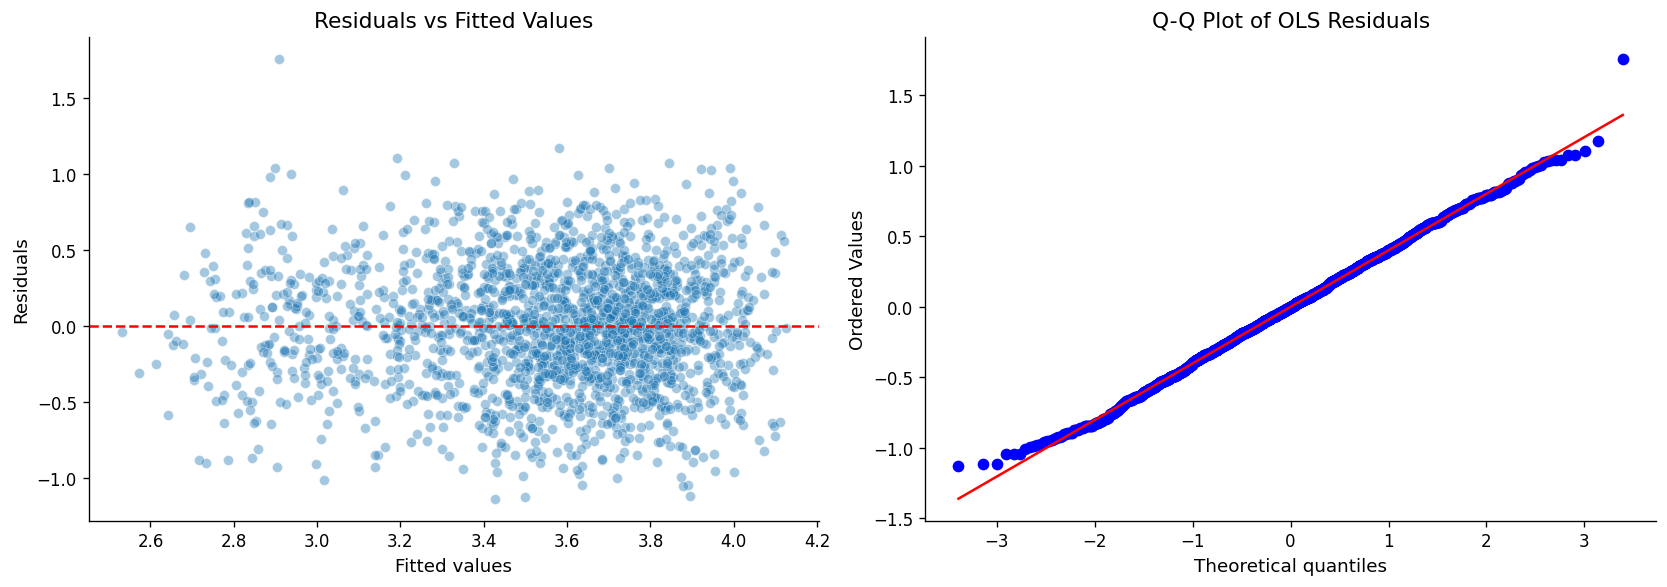

In [84]:
fitted_values = ols_model.fittedvalues
residuals = ols_model.resid
plt.figure(figsize=(14, 5))
# Residuals vs fitted
plt.subplot(1, 2, 1)
sns.scatterplot(x=fitted_values, y=residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
#q-qplot of residuals
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of OLS Residuals")
plt.tight_layout()
plt.show()

**✏️ Your interpretation (A3.2):**

*Do the residuals look randomly scattered around zero? Does the Q-Q plot suggest normally distributed errors? Note any patterns that concern you.*
 residuals vs fitted plot shows that residuals are mostly centered around zero without a strong curved pattern, which suggests the linearity assumption is reasonably satisfied. The spread is not perfectly uniform, but there is no severe funnel shape
The Q-Q plot follows the reference line closely through most of the distribution, with some deviation in the tails, whicch suggests that the residuals are approximately normal, although not perfect. Overall, the log transformation makes the OLS assumptions reasonably defensible for this analysis.


### A4 — Exploratory Interaction Analysis

The average treatment effect hides heterogeneity — the AI assistant may help some users more than others.


**✏️ State your hypothesis here (before writing any code):**

*Which interaction are you testing? Which two variables? What is your theoretical reason for expecting this interaction? Which group do you predict will benefit more from the AI assistant?*

I am going to test whether the ai assistant effect depends on prior whiteboard experience, my hypothesis is that users with fewer prior whiteboard sessions may benefit more from AI access because the assistant could help them navigate the whiteboarding workflow more easily more experienced users may already know how to work efficiently without as much AI support


In [85]:
X_interaction = X.copy()
X_interaction["treatment_x_log_prior_sessions"] = (X_interaction["treatment"] * X_interaction["log_prior_whiteboard_sessions"])
X_interaction_ols = sm.add_constant(X_interaction)
interaction_model = sm.OLS(y, X_interaction_ols).fit()
print(interaction_model.summary())

                                       OLS Regression Results                                      
Dep. Variable:     log_avg_whiteboard_session_duration_min   R-squared:                       0.370
Model:                                                 OLS   Adj. R-squared:                  0.366
Method:                                      Least Squares   F-statistic:                     97.17
Date:                                     Thu, 02 Jul 2026   Prob (F-statistic):          3.38e-189
Time:                                             02:26:58   Log-Likelihood:                -1009.7
No. Observations:                                     2000   AIC:                             2045.
Df Residuals:                                         1987   BIC:                             2118.
Df Model:                                               12                                         
Covariance Type:                                 nonrobust                                         


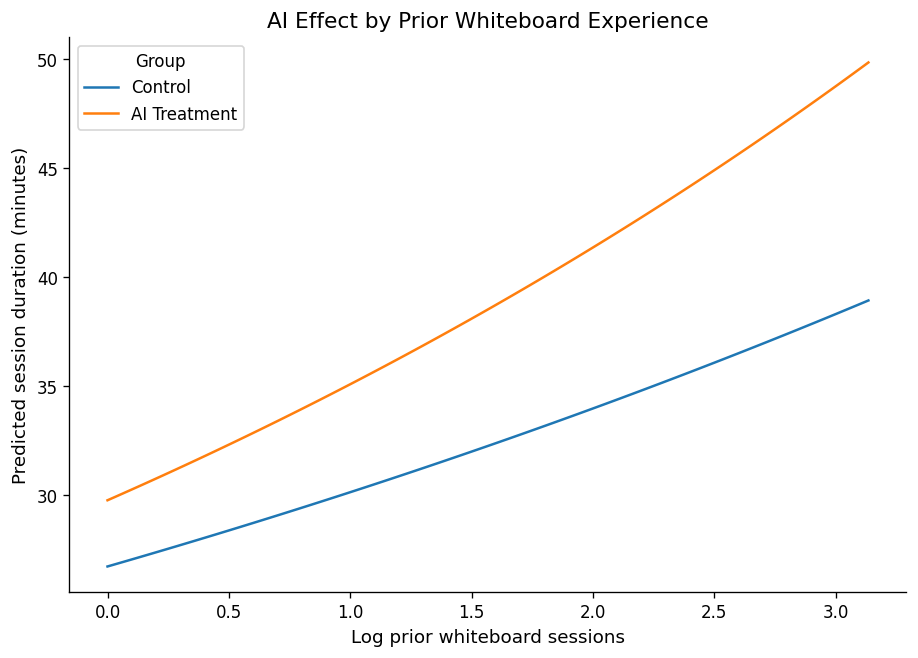

In [87]:
# YOUR CODE HERE
# Visualize the interaction
# Example: plot mean log(outcome) for treatment vs control, split by the moderating variable
# Use a grouped bar chart or overlapping regression lines
prior_grid = np.linspace(X["log_prior_whiteboard_sessions"].min(),X["log_prior_whiteboard_sessions"].max(),100)
base_row = X.mean()
prediction_rows = []

for treatment_value in [0, 1]:
    for prior_value in prior_grid:
        row = base_row.copy()
        row["treatment"] = treatment_value
        row["log_prior_whiteboard_sessions"] = prior_value
        row["treatment_x_log_prior_sessions"] = treatment_value * prior_value
        prediction_rows.append(row)
pred_df = pd.DataFrame(prediction_rows)
pred_df = sm.add_constant(pred_df, has_constant="add")
pred_df["predicted_log_duration"] = interaction_model.predict(pred_df)
pred_df["predicted_duration_minutes"] = np.exp(pred_df["predicted_log_duration"])
pred_df["group"] = np.where(pred_df["treatment"] == 1, "AI Treatment", "Control")
plt.figure(figsize=(9, 6))
sns.lineplot(data=pred_df,x="log_prior_whiteboard_sessions",y="predicted_duration_minutes",hue="group")
plt.title("AI Effect by Prior Whiteboard Experience")
plt.xlabel("Log prior whiteboard sessions")
plt.ylabel("Predicted session duration (minutes)")
plt.legend(title="Group")
plt.show()

**✏️ Your interpretation (A4):**

*Was your hypothesis supported? What does the interaction coefficient tell you about which users benefit most from the AI assistant? What does this imply for how Phigma should roll out the feature?*

tested whether the effect of AI assistant access depends on users prior whiteboard experience, the interaction coefficient between treatment and log prior whiteboard sessions is positive at 0.0445, suggesting that the AI treatment effect may become slightly larger for users with more prior whiteboard experience. However, the interaction is not statistically significant at the 0.05 level because its p-value is 0.105, which means the data does not provide strong enough evidence that the AI assistant effect truly differs by prior whiteboard experience.

The interaction plot shows that treatment users are predicted to have longer sessions than control users across the range of prior whiteboard experience. The treatment line is slightly steeper, which matches the positive interaction coefficient, but the evidence is not strong enough to confidently claim that experienced users benefit more from AI access.
Overall, my original hypothesis was not supported. I expected less experienced users to benefit more from AI assistance, but the model suggests the opposite direction, and the interaction is not statistically significant. From a product perspective, this means Phigma should be cautious about targeting the AI assistant only based on prior whiteboard experience. The main AI treatment effect appears more reliable than the subgroup interaction.

---

## Part B — Logistic Regression: Who Converts?

**Dataset:** `phigma_subscription.csv`  
**Research question:** Which behavioral and demographic factors predict whether a free-tier user subscribes within 30 days?

This dataset requires **feature engineering before modeling**. Several columns arrive as raw datetimes or aggregate counts that need transformation.


In [88]:
df_sub = pd.read_csv('phigma_subscription.csv')

print(f"Shape: {df_sub.shape}")
print(f"\nColumn types:\n{df_sub.dtypes}")
df_sub.head(3)

Shape: (3000, 15)

Column types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1


In [89]:
df_sub.describe(include='all').round(2)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
count,3000,3000,3000,3000,3000,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
unique,2947,181,200,3,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,V43688,2024-06-06,2024-06-27,desktop,tier_1,organic,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,3,33,29,1788,1332,1153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,9.25,216.17,2.43,2.01,1.86,0.68,0.28,3.64,0.21
std,NaN,NaN,NaN,NaN,NaN,NaN,5.09,139.20,2.30,2.05,2.10,1.07,0.45,2.90,0.41
min,NaN,NaN,NaN,NaN,NaN,NaN,1.00,5.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,6.00,115.75,1.00,0.00,0.00,0.00,0.00,2.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,8.00,188.50,2.00,2.00,1.00,0.00,0.00,3.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,12.00,285.00,4.00,3.00,3.00,1.00,1.00,5.00,0.00


### B1 — Feature Engineering

Derive the required features listed in the README before doing any modeling or EDA.


In [90]:
sub = pd.read_csv("phigma_subscription.csv", keep_default_na=False)
print("Shape:", sub.shape)
display(sub.head())
print("\nData types:")
print(sub.dtypes)
print("\nMissing values:")
print(sub.isnull().sum())

Shape: (3000, 15)


,user_id,signup_date,first_session_date,device_type,country_tier,referral_source,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,subscribed
0,V94735,2024-05-23,2024-05-28,tablet,tier_1,organic,1,96,1,0,0,0,1,6,0
1,V15501,2024-03-05,2024-03-05,tablet,tier_2,social,15,267,8,1,5,0,0,0,0
2,V98542,2024-01-05,2024-01-19,desktop,tier_1,organic,16,263,0,0,3,3,1,4,1
3,V14333,2024-04-17,2024-04-18,desktop,tier_2,organic,5,132,3,1,0,1,0,6,1
4,V99172,2024-02-12,2024-02-17,desktop,tier_1,organic,9,108,3,1,2,4,0,4,0



Data types:
user_id                           str
signup_date                       str
first_session_date                str
device_type                       str
country_tier                      str
referral_source                   str
num_sessions_30d                int64
total_time_min_30d              int64
projects_created_30d            int64
exports_30d                     int64
collaborators_invited_30d       int64
support_tickets_30d             int64
used_premium_feature_preview    int64
ai_assistant_sessions_30d       int64
subscribed                      int64
dtype: object

Missing values:
user_id                         0
signup_date                     0
first_session_date              0
device_type                     0
country_tier                    0
referral_source                 0
num_sessions_30d                0
total_time_min_30d              0
projects_created_30d            0
exports_30d                     0
collaborators_invited_30d       0
support_tick

In [91]:
# convert date columns
sub["signup_date"] = pd.to_datetime(sub["signup_date"])
sub["first_session_date"] = pd.to_datetime(sub["first_session_date"])
# days to first session
sub["days_to_first_session"] = (sub["first_session_date"] - sub["signup_date"]).dt.days
# Handle zero session users explicitly to avoid division by zero
sub["avg_session_duration_min"] = np.where(sub["num_sessions_30d"] > 0,sub["total_time_min_30d"] / sub["num_sessions_30d"],0)
# weekend signup
sub["is_weekend_signup"] = sub["signup_date"].dt.dayofweek.isin([5, 6]).astype(int)
tier_map = {"tier_1": 1,"tier_2": 2,"tier_3": 3}
sub["country_tier_encoded"] = sub["country_tier"].map(tier_map)
#  encode device_type and referral_source
device_dummies_sub = pd.get_dummies(sub["device_type"],prefix="device",drop_first=True,dtype=int)
referral_dummies = pd.get_dummies(sub["referral_source"],prefix="referral",drop_first=True,dtype=int)
# feature matrix
subscription_features = ["days_to_first_session","avg_session_duration_min","is_weekend_signup","country_tier_encoded","num_sessions_30d","total_time_min_30d","projects_created_30d","exports_30d","collaborators_invited_30d","support_tickets_30d","used_premium_feature_preview","ai_assistant_sessions_30d"]
X_sub = pd.concat(
    [sub[subscription_features],device_dummies_sub,referral_dummies],axis=1)
y_sub = sub["subscribed"]
X_sub = X_sub.replace([np.inf, -np.inf], np.nan)
print("Feature matrix shape:", X_sub.shape)
print("Outcome shape:", y_sub.shape)
print("\nMissing values in X_sub:")
print(X_sub.isnull().sum())
print("\nInfinite values in X_sub:")
print(np.isinf(X_sub.select_dtypes(include=[np.number])).sum())

print("\nPreview of engineered features:")
display(X_sub.head())

print("\nFinal feature columns:")
print(X_sub.columns.tolist())

Feature matrix shape: (3000, 17)
Outcome shape: (3000,)

Missing values in X_sub:
days_to_first_session           0
avg_session_duration_min        0
is_weekend_signup               0
country_tier_encoded            0
num_sessions_30d                0
total_time_min_30d              0
projects_created_30d            0
exports_30d                     0
collaborators_invited_30d       0
support_tickets_30d             0
used_premium_feature_preview    0
ai_assistant_sessions_30d       0
device_mobile                   0
device_tablet                   0
referral_paid_ad                0
referral_referral               0
referral_social                 0
dtype: int64

Infinite values in X_sub:
days_to_first_session           0
avg_session_duration_min        0
is_weekend_signup               0
country_tier_encoded            0
num_sessions_30d                0
total_time_min_30d              0
projects_created_30d            0
exports_30d                     0
collaborators_invited_30d   

,days_to_first_session,avg_session_duration_min,is_weekend_signup,country_tier_encoded,num_sessions_30d,total_time_min_30d,projects_created_30d,exports_30d,collaborators_invited_30d,support_tickets_30d,used_premium_feature_preview,ai_assistant_sessions_30d,device_mobile,device_tablet,referral_paid_ad,referral_referral,referral_social
0,5,96.0000,0,1,1,96,1,0,0,0,1,6,0,1,0,0,0
1,0,17.8000,0,2,15,267,8,1,5,0,0,0,0,1,0,0,1
2,14,16.4375,0,1,16,263,0,0,3,3,1,4,0,0,0,0,0
3,1,26.4000,0,2,5,132,3,1,0,1,0,6,0,0,0,0,0
4,5,12.0000,0,1,9,108,3,1,2,4,0,4,0,0,0,0,0



Final feature columns:
['days_to_first_session', 'avg_session_duration_min', 'is_weekend_signup', 'country_tier_encoded', 'num_sessions_30d', 'total_time_min_30d', 'projects_created_30d', 'exports_30d', 'collaborators_invited_30d', 'support_tickets_30d', 'used_premium_feature_preview', 'ai_assistant_sessions_30d', 'device_mobile', 'device_tablet', 'referral_paid_ad', 'referral_referral', 'referral_social']


**✏️ Your interpretation (B1):**

*For each engineered feature, one sentence: why might it predict subscription? Also describe how you handled the divide-by-zero edge case for `avg_session_duration_min`.*

I created several behavioral & timing features to make the subscription dataset usable for logistic regressio - `days_to_first_session` measures how quickly a user starts using the product after signup, while `avg_session_duration_min` captures average engagement intensity. I handled users with zero sessions by assigning an average session duration of 0, which avoids division-by-zero or infinite values.

I encoded weekend signup as a binary feature because signup timing may reflect different user intent. I encoded `country_tier` ordinally because the tiers already represent ordered market categories, while `device_type` and `referral_source` were one-hot encoded because they are nominal categories without a natural ranking.

The final feature matrix contains only numeric variables and no missing or infinite values, so it is ready for logistic regression.


### B2 — EDA for Subscription###


In [92]:
# Subscription rate
rate = df_sub['subscribed'].mean()
n_pos = df_sub['subscribed'].sum()
n_total = len(df_sub)
print(f"Subscription rate: {rate:.1%}  ({n_pos} / {n_total})")
print(f"Class balance — 0: {n_total - n_pos}  |  1: {n_pos}")


Subscription rate: 20.8%  (625 / 3000)
Class balance — 0: 2375  |  1: 625


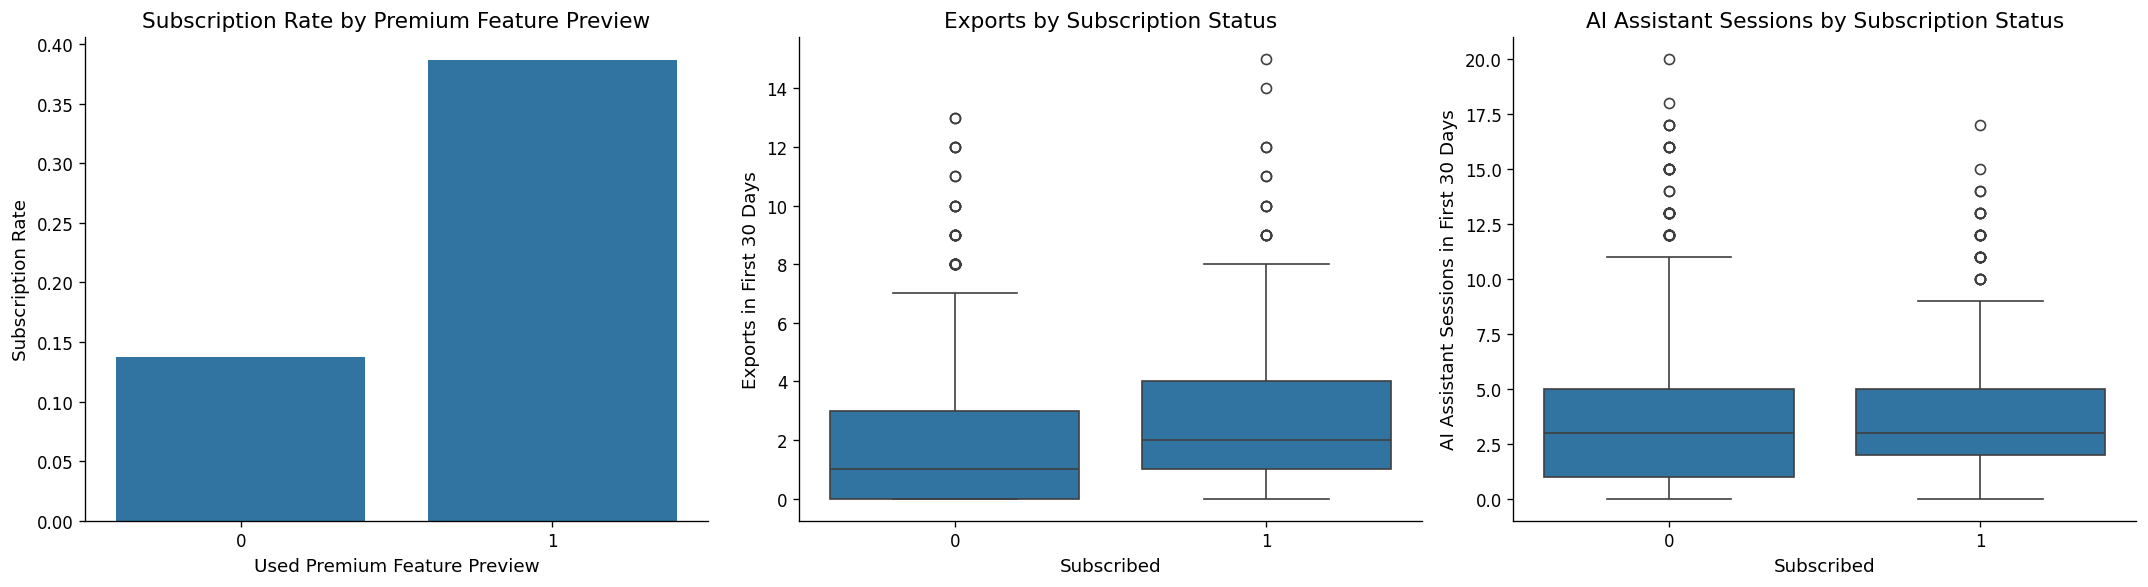

In [94]:
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
premium_rate = sub.groupby("used_premium_feature_preview")["subscribed"].mean().reset_index()
sns.barplot(data=premium_rate,x="used_premium_feature_preview",y="subscribed")
plt.title("Subscription Rate by Premium Feature Preview")
plt.xlabel("Used Premium Feature Preview")
plt.ylabel("Subscription Rate")
# Exports by subscription status
plt.subplot(1, 3, 2)
sns.boxplot(data=sub,x="subscribed",y="exports_30d")
plt.title("Exports by Subscription Status")
plt.xlabel("Subscribed")
plt.ylabel("Exports in First 30 Days")
# AI assistant sessions by subscription status
plt.subplot(1, 3, 3)
sns.boxplot(data=sub,x="subscribed",y="ai_assistant_sessions_30d")
plt.title("AI Assistant Sessions by Subscription Status")
plt.xlabel("Subscribed")
plt.ylabel("AI Assistant Sessions in First 30 Days")
plt.tight_layout()
plt.show()

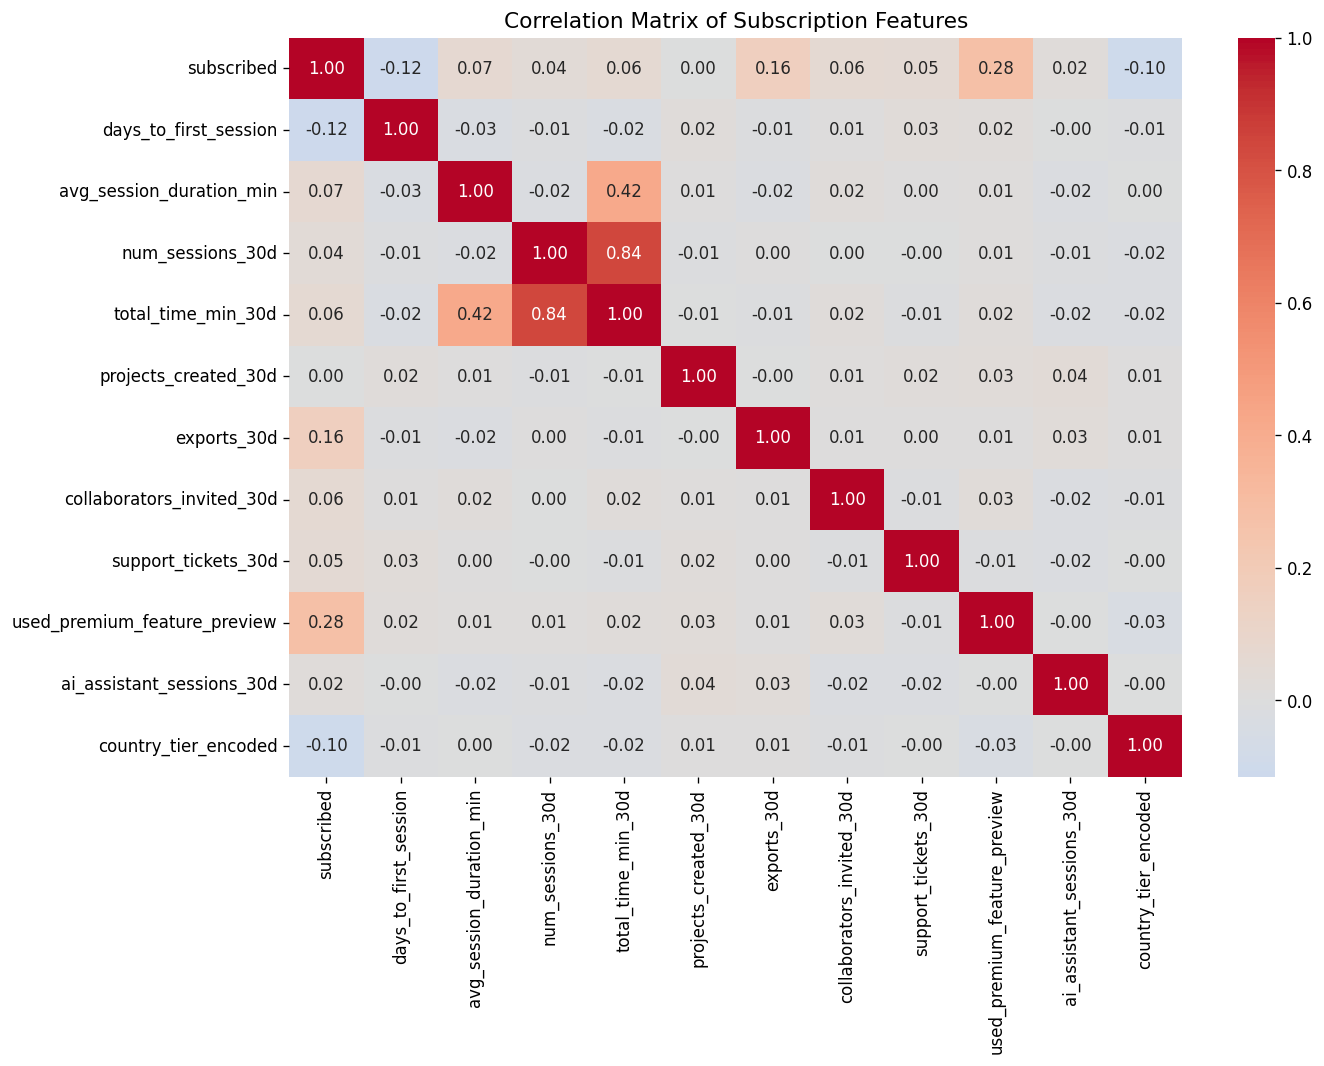

Correlations with subscribed:
subscribed                      1.000000e+00
used_premium_feature_preview    2.762332e-01
exports_30d                     1.628785e-01
avg_session_duration_min        7.183258e-02
total_time_min_30d              6.082856e-02
collaborators_invited_30d       5.554592e-02
support_tickets_30d             5.461930e-02
num_sessions_30d                3.819872e-02
ai_assistant_sessions_30d       2.041977e-02
projects_created_30d            1.865882e-18
country_tier_encoded           -1.015232e-01
days_to_first_session          -1.151436e-01
Name: subscribed, dtype: float64


In [95]:
corr_features = ["subscribed","days_to_first_session","avg_session_duration_min","num_sessions_30d","total_time_min_30d","projects_created_30d","exports_30d","collaborators_invited_30d","support_tickets_30d","used_premium_feature_preview","ai_assistant_sessions_30d","country_tier_encoded"]
corr_matrix = sub[corr_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Matrix of Subscription Features")
plt.show()
print("Correlations with subscribed:")
print(corr_matrix["subscribed"].sort_values(ascending=False))

**✏️ Your interpretation (B2):**

*Which two or three features appear most strongly associated with subscription in your EDA? Are any findings counterintuitive? Note any features that appear highly correlated with each other — does this concern you?*

overall subscription rate is about 21%, meaning the dataset is moderately imbalanced with far more non subscribers than subscribers, this matters because accuracy alone may not be the most reliable evaluation metric later. The strongest visual relationship appears between premium feature preview and subscription: users who clicked into a premium feature have a much higher subscription rate than users who did not. Exports also appear higher among subscribers, suggesting that users who actively produce or export work may be more likely to convert.

 correlation matrix supports this pattern. `used_premium_feature_preview` has the strongest positive correlation with subscription, followed by `exports_30d`. `days_to_first_session` has a negative relationship, suggesting that users who take longer to begin their first session may be less likely to subscribe. One slightly surprising finding is that AI assistant sessions show only a weak correlation with subscription, which suggests AI use alone may not be as strong a conversion signal as premium-feature interest.

### B3 — Logistic Regression with statsmodels (Inferential)

We fit on the **full dataset** here to maximize statistical power for inference.  
No train/test split — the goal is to interpret coefficients, not evaluate prediction.


In [60]:
X_logit = sm.add_constant(X_sub)
logit_model = sm.Logit(y_sub, X_logit).fit()
print(logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.440520
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             subscribed   No. Observations:                 3000
Model:                          Logit   Df Residuals:                     2982
Method:                           MLE   Df Model:                           17
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.1392
Time:                        02:23:49   Log-Likelihood:                -1321.6
converged:                       True   LL-Null:                       -1535.2
Covariance Type:            nonrobust   LLR p-value:                 3.542e-80
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.5253      0.325     -7.772      0.000

In [96]:
# odds ratios for logistic regression

logit_results = pd.DataFrame({"coef": logit_model.params,"p_value": logit_model.pvalues,"odds_ratio": np.exp(logit_model.params)})
logit_results = logit_results.sort_values("p_value")
display(logit_results)
print("Significant predictors (p < 0.05):")
display(logit_results[logit_results["p_value"] < 0.05])

,coef,p_value,odds_ratio
used_premium_feature_preview,1.469474,4.796877e-49,4.346950
exports_30d,0.194102,7.102228e-19,1.214220
const,-2.525339,7.698095e-15,0.080031
days_to_first_session,-0.092729,1.612644e-11,0.911440
country_tier_encoded,-0.356563,5.073127e-08,0.700078
support_tickets_30d,0.154681,3.329027e-04,1.167285
avg_session_duration_min,0.031054,2.289257e-03,1.031542
collaborators_invited_30d,0.061307,5.872426e-03,1.063226
device_tablet,-0.216844,6.602859e-02,0.805055
num_sessions_30d,0.042533,1.225630e-01,1.043450


Significant predictors (p < 0.05):


,coef,p_value,odds_ratio
used_premium_feature_preview,1.469474,4.796877e-49,4.346950
exports_30d,0.194102,7.102228e-19,1.214220
const,-2.525339,7.698095e-15,0.080031
days_to_first_session,-0.092729,1.612644e-11,0.911440
country_tier_encoded,-0.356563,5.073127e-08,0.700078
support_tickets_30d,0.154681,3.329027e-04,1.167285
avg_session_duration_min,0.031054,2.289257e-03,1.031542
collaborators_invited_30d,0.061307,5.872426e-03,1.063226


**✏️ Results paragraph (B3):**

*Interpret at least three odds ratios in plain English (e.g. "Users who previewed a premium feature were X times more likely to subscribe..."). Identify at least one predictor whose sign or magnitude surprised you and offer an explanation.*

 logistic regression model shows that premiu feature interest is the strongest predictor of subscription. Users who previewed a premium feature had about 4.35 times higher odds of subscribing, holding the other variables constant.

Exports were also positively associated with subscription. Each additional export increased the odds of subscribing by about 21%, suggesting that users who produce and export work are more likely to convert. In contrast, `days_to_first_session` had an odds ratio below 1, meaning users who waited longer before starting their first session were less likely to subscribe.

One interesting finding is that support tickets were positively associated with subscription. This may seem surprising because support tickets can indicate friction, but they may also signal that a user is invested enough in the product to ask for help. Overall, the model suggests that subscription is driven more by premium feature interest and productive engagement than by AI assistant usage alone.


### B4 — Logistic Regression with sklearn (Predictive)


In [97]:
# YOUR CODE HERE
# ROC curve (save fpr_lr, tpr_lr for later comparison with Part C)
# B4 — Predictive Logistic Regression with sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix,classification_report,roc_auc_score,roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# 80/20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(X_sub,y_sub,test_size=0.20,stratify=y_sub,random_state=42)

# Logistic regression pipeline with scaling
log_reg_pipeline = Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=1000))])
# Fit model
log_reg_pipeline.fit(X_train, y_train)
# Predictions
y_pred_logreg = log_reg_pipeline.predict(X_test)
y_prob_logreg = log_reg_pipeline.predict_proba(X_test)[:, 1]
# Metrics
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("Confusion Matrix:")
print(cm_logreg)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))
print("ROC-AUC:", auc_logreg)

Confusion Matrix:
[[460  15]
 [103  22]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89       475
           1       0.59      0.18      0.27       125

    accuracy                           0.80       600
   macro avg       0.71      0.57      0.58       600
weighted avg       0.77      0.80      0.76       600

ROC-AUC: 0.7373473684210525


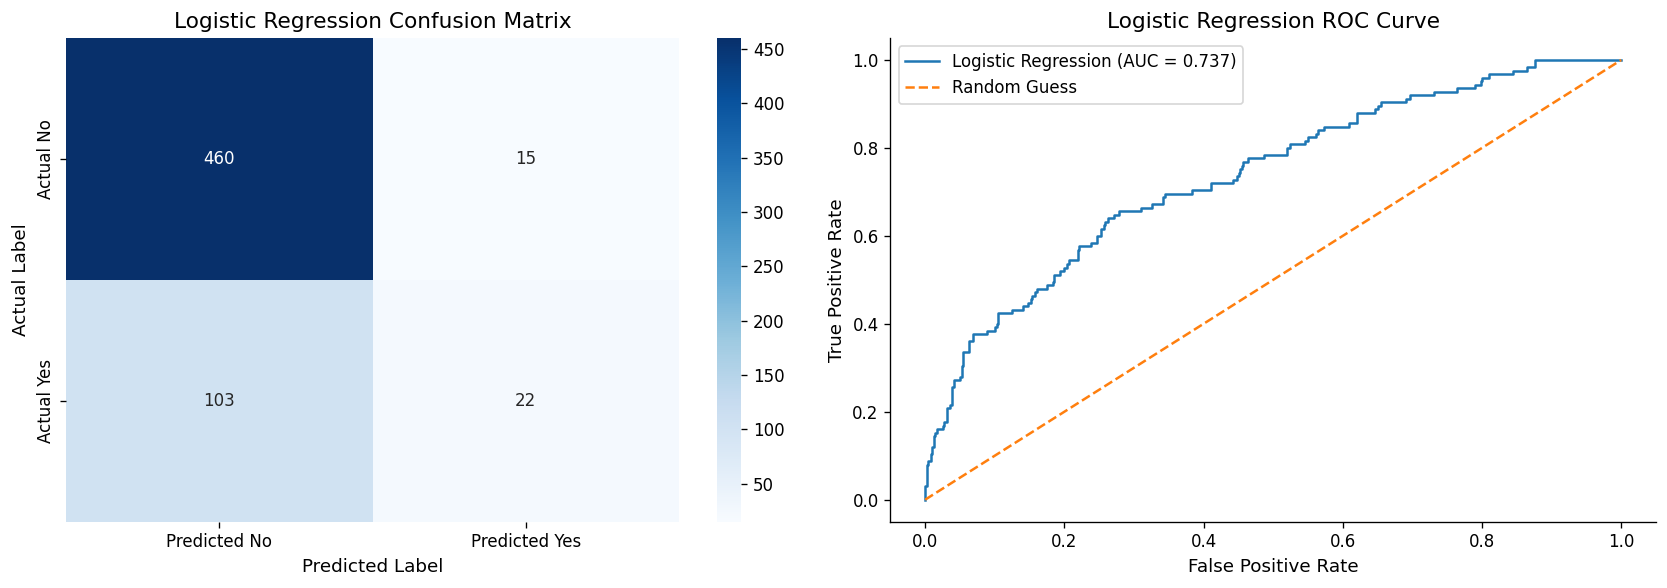

In [98]:
plt.figure(figsize=(14, 5))
# Confusion matrix heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm_logreg,annot=True,fmt="d",cmap="Blues",xticklabels=["Predicted No", "Predicted Yes"],yticklabels=["Actual No", "Actual Yes"])
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
# ROC curve
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_prob_logreg)
plt.subplot(1, 2, 2)
plt.plot(fpr_logreg, tpr_logreg, label=f"Logistic Regression (AUC = {auc_logreg:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("Logistic Regression ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

**✏️ Your interpretation (B4):**

*Which metric did you decide is most important given the class imbalance, and why? Interpret the confusion matrix: how many false negatives does the model produce? From Phigma's business perspective, what is the cost of a false negative (a user who would have subscribed but the model missed)?*
The predictive logistic regression model achieved an accuracy of 0.80 and a ROC-AUC of about 0.737. The ROC-AUC suggests that the model has moderate ability to separate subscribers from non-subscribers. However, accuracy is not the most informative metric here because only about 21% of users subscribed. The model performs very well for non-subscribers, with recall of 0.97 for class 0, but it performs poorly for subscribers, with recall of only 0.18 for class 1.

The confusion matrix shows 103 false negatives, meaning 103 users who actually subscribed were predicted as non-subscribers. From Phigma’s business perspective, this matters because these are users with conversion potential who might be missed by targeting campaigns or onboarding interventions because the positive class is relatively rare and business-relevant, I would focus more on recall, F1-score, and ROC-AUC than accuracy alone. Overall, the model is useful as a baseline, but it is too conservative in predicting subscriptions.


---

## Part C — Your Model: Choose, Learn, Apply, Compare

**Dataset:** `phigma_subscription.csv`  
**Same train/test split as B4.** Do not re-split.


### C1 — Choose Your Model

Available options: Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM, K-Nearest Neighbors, Naive Bayes, SVM, LDA, AdaBoost.


**✏️ Your chosen model:** `[Random Forest]`

**Conceptual explanation (write this before any code):**

*3–5 sentences. How does this model learn from training data? What does it optimize? How is it structurally different from logistic regression? Why might it perform differently on this particular dataset given what you know about the features?*
I chose a Random Forest classifier as the second model because it can capture non linear relationships and interactions between features without needing me to manually specify them. A Random Forest works by training many decision trees on different bootstrapped samples of the data, then combining their predictions through majority voting. Unlike logistic regression, which assumes a mostly linear relationship between predictors and log-odds, Random Forest can detect more flexible patterns in user behavior. This may help in the subscription dataset because conversion may depend on combinations of behaviors, such as premium feature previews, exports, and engagement intensity.


### C2 — Fit and Evaluate


In [99]:
# YOUR CODE HERE
from sklearn.ensemble import RandomForestClassifier

# Fit Random Forest using the same train/test split from B4
rf_model = RandomForestClassifier(random_state=42,n_estimators=200,class_weight="balanced")
rf_model.fit(X_train, y_train)
# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
cm_rf = confusion_matrix(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest Confusion Matrix:")
print(cm_rf)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test,y_pred_rf,target_names=["Not subscribed", "Subscribed"]))

print("Random Forest ROC-AUC:", auc_rf)

Random Forest Confusion Matrix:
[[469   6]
 [107  18]]

Random Forest Classification Report:
                precision    recall  f1-score   support

Not subscribed       0.81      0.99      0.89       475
    Subscribed       0.75      0.14      0.24       125

      accuracy                           0.81       600
     macro avg       0.78      0.57      0.57       600
  weighted avg       0.80      0.81      0.76       600

Random Forest ROC-AUC: 0.6896421052631578


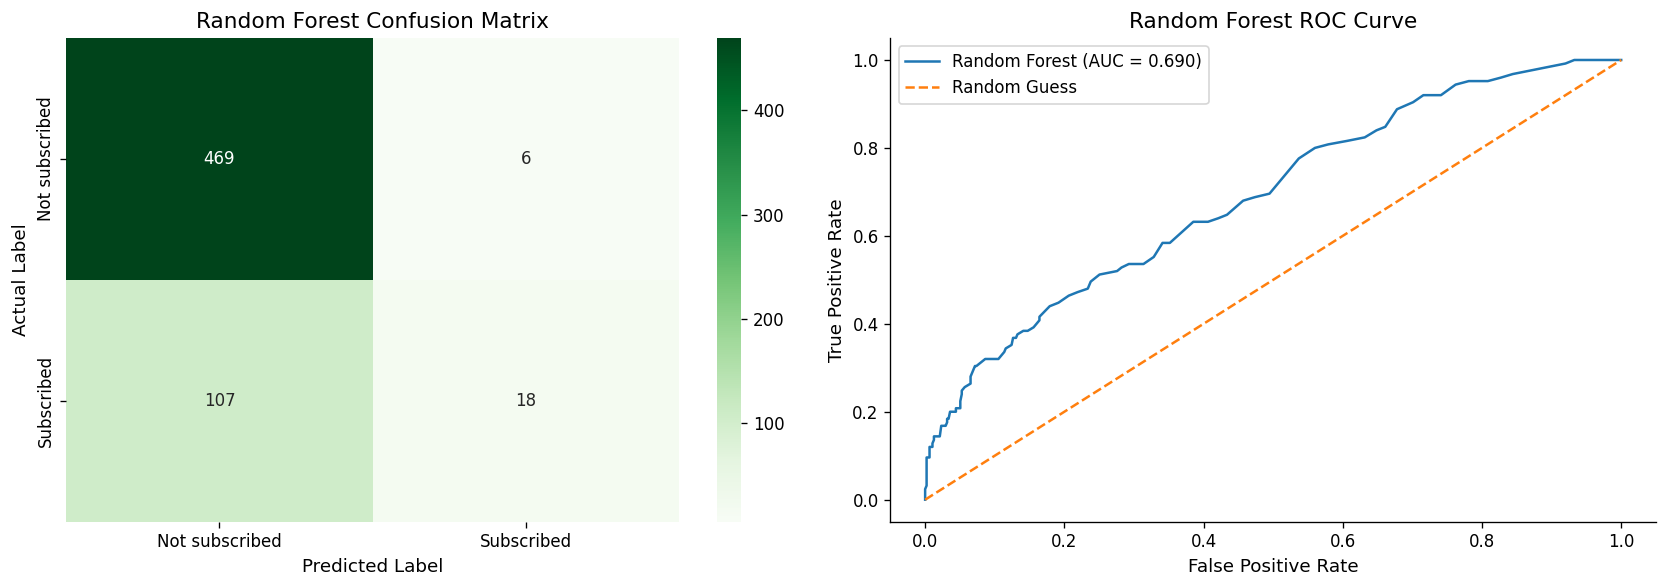

In [100]:

plt.figure(figsize=(14, 5))
# Confusion matrix heatmap
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf,annot=True,fmt="d",cmap="Greens",xticklabels=["Not subscribed", "Subscribed"],yticklabels=["Not subscribed", "Subscribed"])
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
# ROC curve
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.subplot(1, 2, 2)
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.show()

In [101]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest"],"Precision": [precision_score(y_test, y_pred_logreg),precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_logreg),recall_score(y_test, y_pred_rf)],
    "F1": [f1_score(y_test, y_pred_logreg),f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [auc_logreg,auc_rf]
})

display(comparison)

,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.594595,0.176,0.271605,0.737347
1,Random Forest,0.750000,0.144,0.241611,0.689642


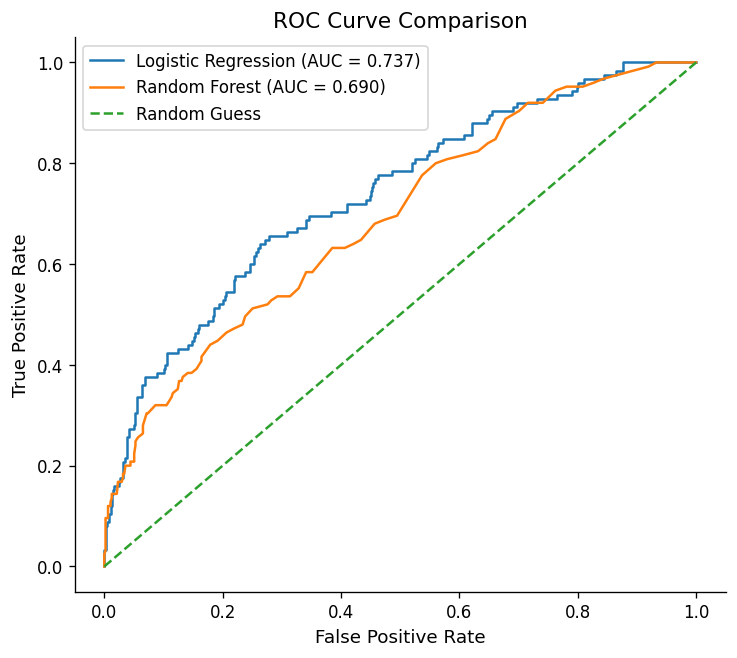

In [102]:
plt.figure(figsize=(7, 6))
plt.plot(fpr_logreg,tpr_logreg,label=f"Logistic Regression (AUC = {auc_logreg:.3f})")
plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### C3 — Model Comparison


In [103]:
# YOUR CODE HERE
# Summary comparison table
from sklearn.metrics import precision_score, recall_score, f1_score
comparison = pd.DataFrame({"Model": ["Logistic Regression", "Random Forest"],"Precision": [precision_score(y_test, y_pred_logreg),precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_logreg),recall_score(y_test, y_pred_rf)],
    "F1": [f1_score(y_test, y_pred_logreg), f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [auc_logreg,auc_rf]})
display(comparison)


,Model,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.594595,0.176,0.271605,0.737347
1,Random Forest,0.750000,0.144,0.241611,0.689642


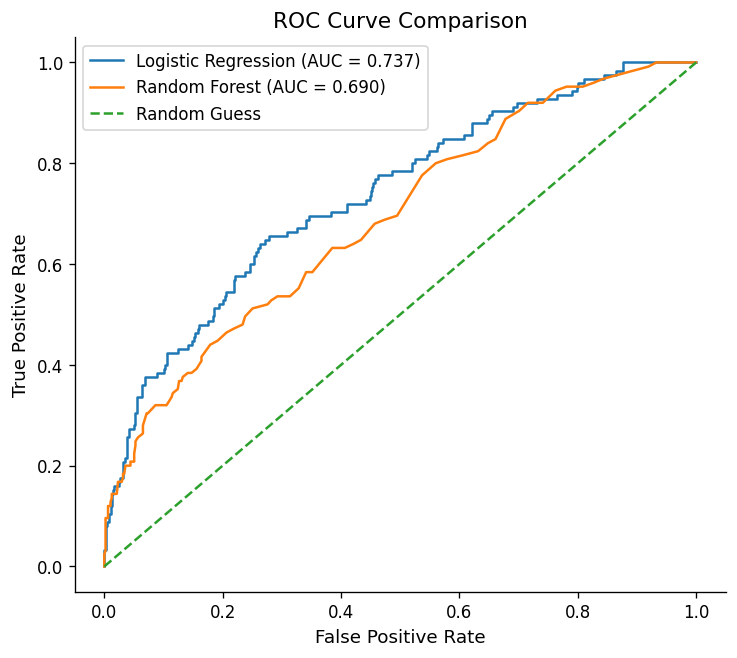

In [104]:
# YOUR CODE HERE
# Dual ROC curve plot
# C3 Combined ROC Curves
plt.figure(figsize=(7, 6))

plt.plot(fpr_logreg,tpr_logreg,label=f"Logistic Regression (AUC = {auc_logreg:.3f})")
plt.plot(fpr_rf,tpr_rf,label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


**✏️ Comparison paragraph (C3):**

*Which model performs better, and by how much? Explain *why* the performance difference occurred — based on what you know about how each model works and the structure of this dataset (non-linearities, class imbalance, number of features). If your model performed worse than logistic regression, that is a valid finding — explain why.*

Logistic Regression performed better overall than Random Forest on this prediction task- Although Random Forest had higher precision, meaning its positive subscription predictions were more reliable, it had lower recall and lower F1-score, this means it predicted fewer users as subscribers and missed more actual subscribers.

The ROC-AUC comparison also favors Logistic Regression, with an AUC of 0.737 compared with 0.690 for Random Forest. This suggests Logistic Regression separates subscribers from non-subscribers more effectively across classification thresholds.

This result is important because a more complex model is not automatically better, random Forest can capture non linear relationships- but in this dataset the signal appears to be relatively simple and well captured by Logistic Regression, especially through variables like premium feature preview, exports, and time to first-session. From a business perspective, logistic regression is the stronger baseline because it has better overall discrimination and better recall for potential subscribers.


### C4 — Bonus: Hyperparameter Tuning (+5 points)

*Complete this section only if you want to attempt the bonus.*


In [105]:
# YOUR CODE HERE (BONUS)
# from sklearn.model_selection import GridSearchCV  # or RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
# Parameter grid for Random Forest
param_grid = {"n_estimators": [100, 200, 300],"max_depth": [None, 5, 10],"min_samples_split": [2, 5],"class_weight": ["balanced"]}
# Grid search with 5-fold cross-validation
rf_grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,scoring="roc_auc",n_jobs=-1)
# Fit only on training data
rf_grid.fit(X_train, y_train)
print("Best parameters:", rf_grid.best_params_)
print("Best CV ROC-AUC:", rf_grid.best_score_)


Best parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300}
Best CV ROC-AUC: 0.7291368421052631


In [106]:
# Evaluate tuned Random Forest on test set
best_rf = rf_grid.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]
auc_rf_tuned = roc_auc_score(y_test, y_prob_rf_tuned)
print("Tuned Random Forest Classification Report:")
print(classification_report(y_test,y_pred_rf_tuned, target_names=["Not subscribed", "Subscribed"]))
print("Default Random Forest test ROC-AUC:", auc_rf)
print("Tuned Random Forest test ROC-AUC:", auc_rf_tuned)

Tuned Random Forest Classification Report:
                precision    recall  f1-score   support

Not subscribed       0.86      0.79      0.82       475
    Subscribed       0.39      0.50      0.44       125

      accuracy                           0.73       600
     macro avg       0.62      0.64      0.63       600
  weighted avg       0.76      0.73      0.74       600

Default Random Forest test ROC-AUC: 0.6896421052631578
Tuned Random Forest test ROC-AUC: 0.7184336842105263


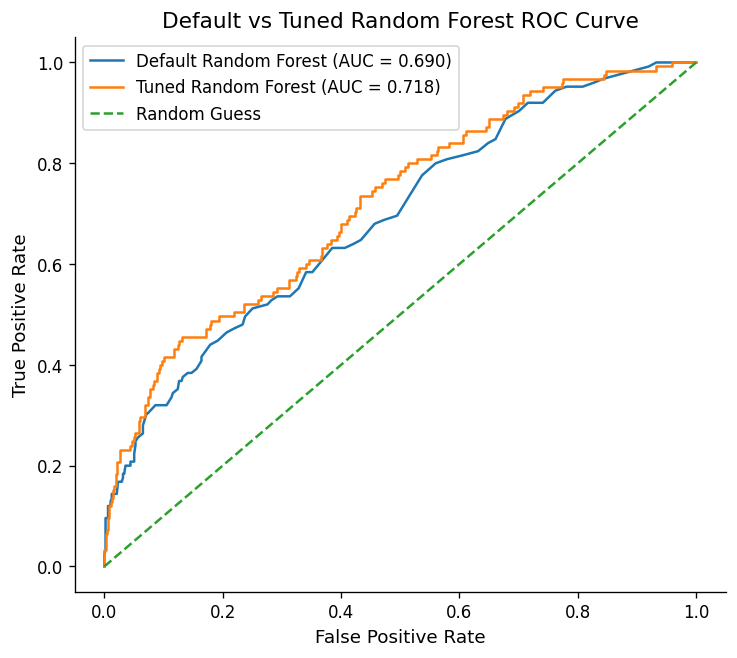

In [107]:
# Tuned Random Forest ROC curve
fpr_rf_tuned, tpr_rf_tuned, thresholds_rf_tuned = roc_curve(y_test, y_prob_rf_tuned)
plt.figure(figsize=(7, 6))
plt.plot(fpr_rf,tpr_rf,label=f"Default Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_rf_tuned,tpr_rf_tuned,label=f"Tuned Random Forest (AUC = {auc_rf_tuned:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title("Default vs Tuned Random Forest ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

### C4
hyperparameter tuning improved the Random Forest test ROC-AUC from 0.690 to 0.718- so tuning produced a modest but meaningful improvement, the tuned model also increased recall for subscribers to 0.50, meaning it identified more actual subscribers than the default Random Forest. However, even after tuning, its ROC-AUC remained slightly below Logistic Regression, so tuning helped but did not make Random Forest the strongest overall model.

---

## Submission Checklist

Before submitting, confirm:

- [x] All `# YOUR CODE HERE` cells are completed and run without errors
- [x] All `**✏️ Your interpretation**` cells contain your own written analysis
- [x] The notebook runs top-to-bottom without errors (`Kernel > Restart & Run All`)
- [x] File is named `iat461_a2_[YourName]_[SFUid].ipynb`
- [x] PDF export is named `iat461_a2_[YourName]_[SFUid].pdf`
- [--] All AI-assisted code blocks include `#BEGIN` / `#END` disclosure comments
